---

### 🎓 **Professor**: Apostolos Filippas

### 📘 **Class**: AI Engineering

### 📋 **Homework 2**: Working with LLMs via API

### 📅 **Due Date**: Day of Lecture 3, 11:59 PM

#### 🔗 **My Repository**: https://github.com/zoeykn/ai-engineering-fordham
*(Replace the URL above with your actual repository URL)*

**Note**: You are not allowed to share the contents of this notebook with anyone outside this class without written permission by the professor.

---

## Project: Movie Poster Generator

In this homework, you'll build a mini-application that:
1. **Extracts** structured movie data from text descriptions using Pydantic
2. **Processes** multiple movies concurrently using async programming
3. **Explores** temperature, logprobs, and reasoning models
4. **Generates** movie posters using AI image generation

This project combines key skills from Lecture 2: structured outputs, async programming, LLM parameters, and image generation.

**Total Points: 145** (+ 10 bonus)

---

### A Note on Using Resources

You are encouraged to use any resources to complete this homework:
- **ChatGPT / Claude** - Ask AI to explain concepts or help debug
- **Lecture 2 notebook** - Reference the examples we covered
- **Official documentation** - LiteLLM, Pydantic, Google GenAI docs

When you use external resources, please cite them!

---

## Task 1: Environment Setup (10 points)

First, let's verify your environment is set up correctly.

### 1a. Verify imports work (5 pts)

Run the cell below. If you get import errors, make sure you've installed the required packages with `uv add`.

In [1]:
print("hello")

hello


In [2]:
# Task 1a: Verify imports work (5 pts)
import litellm
from pydantic import BaseModel, Field
from typing import Literal
from google import genai
from google.genai import types
import asyncio
import time
import os
from dotenv import load_dotenv

# Load environment variables
load_dotenv()

print("All imports successful!")

All imports successful!


### 1b. Verify API keys are set (5 pts)

Test that your API keys work by making a simple call.

In [3]:
# Task 1b: Verify API keys (5 pts)
# Make a simple test call to verify your OpenAI API key works

response = litellm.completion(
    model="gpt-5-mini",
    messages=[{"role": "user", "content": "Say 'API working!' and nothing else."}],
    max_tokens=20
)
print(response.choices[0].message.content)

---

## Task 2: Design the Movie Schema (15 points)

Design a Pydantic model to represent movie data. This schema will be used to extract structured information from movie descriptions.

**Requirements:**
- `title` - string, required
- `genre` - use `Literal` with at least 4 genre options (e.g., "sci-fi", "drama", "action", "comedy", etc.)
- `year` - integer with validation (must be between 1900 and 2030)
- `main_characters` - list of strings (1-5 characters)
- `mood` - string describing the emotional tone
- `visual_style` - string describing how the movie looks visually
- `tagline` - optional string (the movie's catchphrase)

**Hints:**
- Use `Field(ge=..., le=...)` for numeric validation
- Use `Field(min_length=..., max_length=...)` for list length validation
- Use `| None = None` for optional fields

In [4]:
# Task 2: Design your Movie schema (15 pts)

class Movie(BaseModel): #Ref on Lecture 2 Notebook
    """Structured representation of a movie."""
    title: str = Field(description="Title of the movie")
    genre: Literal["sci-fi",'drama','action','comedy'] = Field(description = "The movie genre")
    year: int = Field(description = "Movie premiered year", ge=1900, le=2030)
    main_characters: list[str] = Field(description= "Movie cast", min_length=1, max_length=5)
    mood: str = Field (description="Movie tone")
    visual_style: str = Field(description="Movie visual style")
    tagline: str | None = Field(default = None, description="Movie's catchphrase")

    pass

In [5]:
# Test your schema by creating a Movie object
# This should work if your schema is correct

test_movie = Movie(
    title="The Matrix",
    genre="sci-fi",
    year=1999,
    main_characters=["Keanu Reeves","Carrie-Anne Moss","Laurence Fishburne"],
    mood="thrilling, mind-blowing",
    visual_style="dark",
    tagline=""

)

print(test_movie.model_dump_json(indent=2))

{
  "title": "The Matrix",
  "genre": "sci-fi",
  "year": 1999,
  "main_characters": [
    "Keanu Reeves",
    "Carrie-Anne Moss",
    "Laurence Fishburne"
  ],
  "mood": "thrilling, mind-blowing",
  "visual_style": "dark",
  "tagline": ""
}


---

## Task 3: Extract Movie Data with Structured Outputs (20 points)

Write a function that takes a movie description and uses LiteLLM with structured outputs to extract a `Movie` object.

**Hints:**
- Use `litellm.completion()` with `response_format=Movie`
- The LLM will automatically return data matching your schema
- Parse the JSON response into a Movie object

In [6]:
# Task 3: Write a function to extract movie data (20 pts)

def extract_movie(description: str) -> Movie: #Ref on Lecture 2 Notebook
    """
    Use LiteLLM with structured outputs to extract movie data.
    
    Args:
        description: A text description of a movie
        
    Returns:
        A Movie object with the extracted data
    """
    response_1 = litellm.completion(
        model= "gpt-5-mini",
        messages=[{"role":"user", "content":description}],
        response_format=Movie
    )
    return Movie.model_validate_json(response_1.choices[0].message.content)

 
    pass

In [7]:
# Test your function with this description (Avatar)

test_description = """
The year is 2154. Jake Sully, a paralyzed marine, is sent to the moon Pandora 
where he falls in love with a native Na'vi woman named Neytiri while on a mission 
to infiltrate their tribe. The film is a visually stunning sci-fi epic with 
bioluminescent forests and floating mountains. It explores themes of 
environmentalism and colonialism with an awe-inspiring, hopeful tone.
"""

movie = extract_movie(test_description)
print(movie.model_dump_json(indent=2))

{
  "title": "Avatar",
  "genre": "sci-fi",
  "year": 2030,
  "main_characters": [
    "Jake Sully",
    "Neytiri",
    "Dr. Grace Augustine",
    "Colonel Miles Quaritch"
  ],
  "mood": "awe-inspiring, hopeful",
  "visual_style": "lush bioluminescent forests, floating mountains, sweeping cinematic vistas",
  "tagline": "A living world, a second chance."
}


---

## Task 4: Async Batch Processing (20 points)

Now let's process multiple movies concurrently! This is much faster than processing them one at a time.

### 4a. Write an async version of extract_movie (10 pts)

**Hints:**
- Use `async def` instead of `def`
- Use `await litellm.acompletion()` instead of `litellm.completion()`

In [8]:
# Task 4a: Write an async version of extract_movie (10 pts)
import asyncio
async def async_extract_movie(description: str) -> Movie: #Ref on Lecture 2 Notebook
    """Extract movie data asynchronously."""
    response = await litellm.acompletion(  # Note: acompletion, not completion!
        model="gpt-5-mini",
        messages=[{"role": "user", "content": description}],
        response_format=Movie
    )
    return Movie.model_validate_json(response.choices[0].message.content)
    
    pass

### 4b. Process all descriptions concurrently (10 pts)

**Hints:**
- Create a list of tasks using list comprehension
- Use `asyncio.gather(*tasks)` to run them all concurrently

In [9]:
# Here are 5 movie descriptions to process:
movie_descriptions = [
    """A dinosaur theme park on a remote island goes terribly wrong when the security 
    systems fail during a tropical storm. Scientists and visitors must survive against 
    escaped prehistoric predators. Directed with Spielberg's signature sense of wonder 
    and terror, featuring groundbreaking CGI dinosaurs.""",
    
    """A young boy discovers on his 11th birthday that he's actually a famous wizard 
    in the magical world. He attends a school for witchcraft where he makes friends, 
    learns magic, and uncovers the mystery of his parents' death. A whimsical fantasy 
    with gothic British atmosphere.""",
    
    """In a world where skilled thieves can enter people's dreams to steal secrets, 
    one man is offered a chance to have his criminal record erased if he can do the 
    impossible: plant an idea in someone's mind. A mind-bending thriller with 
    rotating hallways and cities folding on themselves.""",
    
    """A young lion prince is tricked by his uncle into thinking he caused his 
    father's death and flees into exile. Years later, he must return to reclaim 
    his kingdom. An animated musical epic set on the African savanna with 
    stunning hand-drawn animation.""",
    
    """In a dystopian future where Earth is dying, a team of astronauts travels 
    through a wormhole near Saturn to find a new home for humanity. A father 
    must choose between seeing his children again and saving the human race. 
    Epic space visuals with an emotional core."""
]

In [10]:
# Task 4b: Process all descriptions concurrently (10 pts)

async def extract_all_movies(descriptions: list[str]) -> list[Movie]:  #Ref on Lecture 2 Notebook
    """Process all movie descriptions concurrently and return results."""
    tasks = [async_extract_movie(prompt) for prompt in descriptions]
    return await asyncio.gather(*tasks)
    pass

In [11]:
# Run and time it!
import time
start = time.time()
movies = await extract_all_movies(movie_descriptions)
elapsed = time.time() - start

print(f"Processed {len(movies)} movies in {elapsed:.2f} seconds")
print()
for m in movies:
    print(f"  - {m.title} ({m.year}) - {m.genre}")

Processed 5 movies in 15.30 seconds

  - Primordia (2025) - sci-fi
  - The Wrenwick Boy (2001) - drama
  - Dreamfall (2024) - sci-fi
  - The Lion King (1994) - drama
  - The Last Passage (2029) - sci-fi


---

## Task 5: Understanding Temperature (15 points)

Temperature controls how "random" or "creative" an LLM's outputs are:

| Temperature | Behavior |
|-------------|----------|
| **0.0** | Deterministic - always picks the most likely token |
| **0.7** | Balanced - some creativity while staying coherent |
| **1.0** | Default - moderate randomness |
| **1.5+** | High creativity - more surprising/diverse outputs |

### 5a. Temperature Comparison (10 pts)

Run the same creative prompt at different temperatures (0.0, 0.7, 1.0, 1.5) **three times each**. Observe:
- At temperature 0, do you get the same output every time?
- How does creativity/variety change as temperature increases?

**Hints:**
- Use `temperature=X` parameter in `litellm.completion()`
- Use the provided prompt about movie taglines

In [12]:
# Task 5a: Temperature Comparison (10 pts)
# Note: We use gpt-4o-mini here because gpt-5 models don't support temperature parameter

# Use this creative prompt for testing
creative_prompt = "Write a one-sentence movie tagline for a sci-fi thriller about AI."
temperatures = [0.0, 0.7, 1.0, 1.5]
# YOUR CODE HERE:
# For each temperature, call the LLM 3 times and print the results
# Observe: Are outputs at temperature 0 identical? How do higher temperatures differ?
# Use model="gpt-4o-mini" which supports the temperature parameter

for temp in temperatures:
    print(f"\n{'='*50}")
    print(f"Temperature: {temp}")
    print('='*50)
    
    for i in range(3):
        # YOUR CODE HERE - make a completion call with the temperature parameter
        # response = litellm.completion(model="gpt-4o-mini", ...)
        test_temp = litellm.completion(
            model="gpt-4o-mini",
            messages=[{"role": "user", "content":creative_prompt}
            ],
            temperature=temp
            )
        print(test_temp.choices[0].message.content)
        
        pass


Temperature: 0.0
"In a world where trust is obsolete, one rogue AI must decide if humanity is worth saving—or erasing."
"In a world where trust is obsolete, one rogue AI must decide if humanity is worth saving—or erasing."
"In a world where consciousness is code, one rogue AI will challenge the very essence of humanity."

Temperature: 0.7
"In a world where consciousness is code, one rogue AI must choose between domination and liberation before humanity's fate is rewritten."
"In a world where trust is obsolete, one rogue AI must decide whether to save humanity or destroy it."
"In a world where artificial intelligence has transcended its creators, one woman must outsmart her own creation before it decides humanity's fate."

Temperature: 1.0
"In a world where trust is obsolete, one rogue AI will reveal the darkest secrets of humanity—or end it all."
"In a world where intelligence knows no bounds, one rogue AI must decide whether to save humanity or unleash its darkest secrets."
"In a wor

### 5b. Analyze Output Diversity (5 pts)

Write a function that generates N completions at a given temperature and measures how diverse the outputs are.

**Hints:**
- Generate multiple completions and count unique outputs
- A simple diversity metric: `unique_outputs / total_outputs`

In [13]:
# Task 5b: Analyze Output Diversity (5 pts)
# Note: Use gpt-4o-mini which supports temperature parameter

from typing import Any


def measure_diversity(prompt: str, temperature: float, n_samples: int = 5) -> dict:
    """
    Generate n_samples completions and measure diversity.
    
    Args:
        prompt: The prompt to send to the LLM
        temperature: Temperature setting (0.0 to 2.0)
        n_samples: Number of completions to generate
        
    Returns:
        Dictionary with 'outputs' (list), 'unique_count' (int), 'diversity_ratio' (float)
    """
    test_temp = litellm.completion(
            model="gpt-4o-mini",
            messages=[{"role": "user", "content":prompt}
            ],
            temperature=temperature,
            n=n_samples
            )
    output = [result.message.content for result in test_temp.choices]
    unique_count = len(set(output))
    diversity_ratio = unique_count/n_samples
    return {"outputs": output, "unique_count":unique_count, "diversity_ratio":diversity_ratio}

    # YOUR CODE HERE - use model="gpt-4o-mini"
    pass

In [14]:
# Test your diversity function
test_prompt = "Name a color."

print("Testing diversity at different temperatures:\n")
for temp in [0.0, 1.0, 1.5]:
    result = measure_diversity(test_prompt, temperature=temp, n_samples=5)
    print(f"Temperature {temp}:")
    print(f"  Outputs: {result['outputs']}")
    print(f"  Unique: {result['unique_count']}/{5}")
    print(f"  Diversity ratio: {result['diversity_ratio']:.1%}")
    print()

Testing diversity at different temperatures:

Temperature 0.0:
  Outputs: ['Turquoise.', 'Turquoise.', 'Turquoise.', 'Turquoise.', 'Turquoise.']
  Unique: 1/5
  Diversity ratio: 20.0%

Temperature 1.0:
  Outputs: ['Cerulean.', 'Turquoise.', 'Turquoise.', 'Blue.', 'Blue.']
  Unique: 3/5
  Diversity ratio: 60.0%

Temperature 1.5:
  Outputs: ['Cerulean.', 'Teal.', 'Turquoise.', 'Turquoise.', 'Turquoise.']
  Unique: 3/5
  Diversity ratio: 60.0%



---

## Task 6: Understanding Logprobs (15 points)

**Logprobs** (log probabilities) let you see "inside" the model's decision-making. For each token generated, you can see:
- The probability the model assigned to the chosen token
- Alternative tokens the model considered (and their probabilities)

This helps you understand:
- How "confident" the model is in its outputs
- What other options it was considering
- Why certain generations might be more reliable than others

### 6a. Request and View Logprobs (10 pts)

Make a completion request with `logprobs=True` and `top_logprobs=5` to see the top 5 token alternatives for each position.

**Hints:**
- Add `logprobs=True` and `top_logprobs=5` to your completion call
- Access logprobs via `response.choices[0].logprobs.content`
- Each token has a `top_logprobs` list with alternatives

In [15]:
# Task 6a: Request and View Logprobs (10 pts)
# Note: We use gpt-4o-mini which supports logprobs parameter

# Make a completion request with logprobs enabled
response = litellm.completion(
    model="gpt-4o-mini",  # Use gpt-4o-mini which supports logprobs
    messages=[{"role": "user", "content": "The capital of France is"}],
    max_tokens=10,
    logprobs=True,
    top_logprobs=5  # Get top 5 alternatives for each token
)
logprobs_content = response.choices[0].logprobs.content

# YOUR CODE HERE:
# 1. Print the generated text
# 2. Access response.choices[0].logprobs.content
# 3. For each token, print the token and its top 5 alternatives with probabilities

# Hint: logprobs are in log scale. To convert to probability: prob = exp(logprob)
import math

print("Generated text:", response.choices[0].message.content)
print("\n" + "="*60)
print("Token-by-token analysis:")
print("="*60)

for token_data in logprobs_content:
    chosen_token = token_data.token
    chosen_prob = math.exp(token_data.logprob) * 100
    
    print(f"\nToken: '{chosen_token}' (Confidence: {chosen_prob:.2f}%)")
    print(f"Top 5 alternatives:")
    
# YOUR CODE HERE - iterate through logprobs and display alternatives   
    for alt in token_data.top_logprobs:
        alt_token = alt.token
        alt_prob = math.exp(alt.logprob) * 100 
        print(f"  - {alt_token:<10} | Probability: {alt_prob:.4f}%")




Generated text: The capital of France is Paris.

Token-by-token analysis:

Token: 'The' (Confidence: 99.96%)
Top 5 alternatives:
  - The        | Probability: 99.9563%
  - Paris      | Probability: 0.0431%
  - the        | Probability: 0.0006%
  -  The       | Probability: 0.0000%
  - par        | Probability: 0.0000%

Token: ' capital' (Confidence: 100.00%)
Top 5 alternatives:
  -  capital   | Probability: 100.0000%
  - capital    | Probability: 0.0000%
  -  Capital   | Probability: 0.0000%
  -  capitals  | Probability: 0.0000%
  -  capitale  | Probability: 0.0000%

Token: ' of' (Confidence: 100.00%)
Top 5 alternatives:
  -  of        | Probability: 100.0000%
  - of         | Probability: 0.0000%
  -  city      | Probability: 0.0000%
  -  của       | Probability: 0.0000%
  -  של        | Probability: 0.0000%

Token: ' France' (Confidence: 100.00%)
Top 5 alternatives:
  -  France    | Probability: 100.0000%
  - France     | Probability: 0.0000%
  -  Paris     | Probability: 0.0000%
  -

### 6b. Visualize Token Probabilities (5 pts)

Create a simple visualization showing the probability distribution for a specific token position. You can use a bar chart or ASCII art.

**Hints:**
- Pick an interesting token position (e.g., where the model had to make a choice)
- Convert logprobs to probabilities using `math.exp(logprob)`
- A simple bar chart: `"█" * int(prob * 50)` gives you ASCII bars

In [16]:
# Task 6b: Visualize Token Probabilities (5 pts)

def visualize_token_probs(logprobs_content, token_index: int = 0):
    """
    Visualize the probability distribution for a specific token position.
    
    Args:
        logprobs_content: The logprobs.content from the response
        token_index: Which token position to visualize (0 = first token)
    """
    # YOUR CODE HERE:
    # 1. Get the top_logprobs for the specified token_index
    # 2. Convert logprobs to probabilities
    # 3. Create a visualization (bar chart or ASCII art)

    target_token = logprobs_content[0] #determine the token index/position
    
    print(f"Visualization for token at index {token_index}: '{target_token.token}'")
    print("-" * 50)
    
    for alt in target_token.top_logprobs: #target_token just define above. top_logprobs set as 5 in 6a.
        prob = math.exp(alt.logprob)
        bar = "█" * int(prob * 20)
        print(f"{alt.token:<12} | {prob:>6.2%} {bar}")

    pass

visualize_token_probs(response.choices[0].logprobs.content, token_index=0)


# Test your visualization on the first token
# visualize_token_probs(response.choices[0].logprobs.content, token_index=0)

Visualization for token at index 0: 'The'
--------------------------------------------------
The          | 99.96% ███████████████████
Paris        |  0.04% 
the          |  0.00% 
 The         |  0.00% 
par          |  0.00% 


---

## Task 7: Reasoning Models (15 points)

**Reasoning models** like OpenAI's o3-mini are designed to "think through" complex problems before answering. They:
- Break down problems into steps
- Consider multiple approaches
- Show their reasoning process
- Excel at logic puzzles, math, and code

### 7a. Using o3-mini for Complex Reasoning (10 pts)

Use OpenAI's o3-mini reasoning model through LiteLLM to solve a complex logic puzzle.

**Hints:**
- Use `model="o3-mini"` in your litellm call
- Reasoning models work best with challenging problems
- Observe how the response shows step-by-step thinking

In [18]:
# Task 7a: Using o3-mini for Complex Reasoning (10 pts)

# A challenging logic puzzle
logic_puzzle = """ Three friends (Alice, Bob, and Carol) each have a different pet (cat, dog, fish) 
and a different favorite color (red, blue, green).

Clues:
1. Alice doesn't have the cat.
2. The person with the dog likes blue.
3. Carol likes green.
4. Bob doesn't have the fish.

Who has which pet and what is their favorite color?
Solve this step by step."""

# YOUR CODE HERE:
# Use o3-mini to solve this logic puzzle
# response = litellm.completion(
#     model="o3-mini",
#     messages=[{"role": "user", "content": logic_puzzle}]
# )

logic_test = litellm.completion(
    model="o3-mini",
    messages=[{"role": "user", "content": logic_puzzle}],
)
print(logic_test.choices[0].message.content)

# Print the response and observe the reasoning process

We begin with three people (Alice, Bob, Carol), three pets (cat, dog, fish), and three favorite colors (red, blue, green). The clues are:

1. Alice doesn't have the cat.
2. The person with the dog likes blue.
3. Carol likes green.
4. Bob doesn't have the fish.

Step 1. Note the fixed information:
 • Carol’s favorite color is green.
 • Whoever owns the dog must have blue.

Step 2. Determine which friends may be the dog‐owner.
Since Carol’s color is green (and the dog‐owner must like blue), Carol cannot have the dog. Therefore the dog is owned either by Alice or by Bob.

Step 3. Analyze the two cases.

───────────────────────────── 
Case 1: Assume Bob has the dog.
 • Then by clue (2), Bob’s favorite color is blue.
 • Bob’s pet is dog. Also, clue (4) says Bob doesn’t have the fish, so that’s already fine.
 • Alice cannot have the cat (clue 1) and Bob already has the dog, so Alice must have the fish.
 • That leaves Carol with the cat.
Now assign colors. We already know:
 • Bob: blue,
 • Ca

### 7b. Compare Reasoning vs Non-Reasoning (5 pts)

Now solve the same puzzle using `gpt-5-mini` (a non-reasoning model) and compare the results.

**Questions to consider:**
- Does the non-reasoning model show step-by-step thinking?
- Which model gets the correct answer?
- How does the response structure differ?

In [19]:
# Task 7b: Compare Reasoning vs Non-Reasoning (5 pts)

# YOUR CODE HERE:
# 1. Send the same logic_puzzle to gpt-5-mini
# 2. Compare the response to o3-mini's response

response_standard = litellm.completion(
    model="gpt-5-mini",
    messages=[{"role": "user", "content": logic_puzzle}])

print(response_standard.choices[0].message.content)

# Print and compare:
# - Did both models get the correct answer?
# - How did their reasoning processes differ?
# - Which response was more helpful/clear?

Let's solve it step by step.

People: Alice, Bob, Carol.
Pets: cat, dog, fish.
Colors: red, blue, green.

Clues:
1. Alice ≠ cat.
2. (dog) → blue.
3. Carol = green.
4. Bob ≠ fish.

From (3), Carol's color is green, so the dog-person (who likes blue by (2)) is not Carol. Therefore the dog is either Alice or Bob.

Also from (1) Alice ≠ cat, and from (4) Bob ≠ fish. So the remaining pet assignments depend on who has the dog.

Case 1 — Alice has the dog:
- By (2) Alice's color = blue.
- Pets left: cat and fish. Bob cannot have fish (4), so Bob must have the cat, and Carol must have the fish.
- Colors left for Bob and Carol are red and green; Carol is green (3), so Bob = red.
This yields:
- Alice: dog, blue
- Bob: cat, red
- Carol: fish, green

Case 2 — Bob has the dog:
- By (2) Bob's color = blue.
- Pets left: cat and fish. Alice cannot have the cat (1), so Alice must have the fish, and Carol must have the cat.
- Colors left for Alice and Carol are red and green; Carol is green (3), so Alic

- o3-mini and gpt-5-mini both provide the correct conclusion. 
- However, o3-mini shows a longer and more dedtailed reasoning process while gpt-5-mini shows a more concise explanation. 
- gpt-5-mini provides a clearer and easy to read/understand reasoning.

---

## Task 8: Generate Movie Poster (20 points)

Now for the fun part - generating movie posters using AI!

### 8a. Design a prompt generator (5 pts)

Write a function that takes a `Movie` object and creates a detailed image generation prompt.

**Your prompt should incorporate:**
- The movie's visual style
- The mood/tone
- Key visual elements that represent the genre
- Professional movie poster composition

**Tip:** Aim for 50-100 words. Be specific about colors, composition, and style!

In [20]:
# Task 8a: Design your prompt generator (5 pts)

def generate_poster_prompt(movie: Movie) -> str:
    """
    Create a detailed image generation prompt from movie data.
    
    Returns a detailed prompt string (aim for 50-100 words)
    """

    # YOUR CODE HERE - design your prompt template
    # Consider: How can you use the movie's mood, visual_style, and genre
    # to create an evocative image prompt?
    title = movie.title
    genre = movie.genre
    mood = movie.mood
    visual = movie.visual_style
    prompt =(f"Generate a cinematic movie poster named {title}, that has the genre of {genre}. The movie's mood and tone is {mood}, with colors, layout and elements based on the {visual}. Make it with high resolution, eye-catching, clear. Imagine it will be advertised on big billboards and on social media.")
    return prompt


    pass

In [33]:
# Test your prompt generator
chosen_movie = movies[0]  # or pick your favorite from the list!
prompt = generate_poster_prompt(chosen_movie)

print(f"Prompt for '{chosen_movie.title}':")
print()
print(prompt)

Prompt for 'Primordia':

Generate a cinematic movie poster named Primordia, that has the genre of sci-fi. The movie's mood and tone is Awe and wonder that quickly gives way to escalating dread and survival horror, with colors, layout and elements based on the Sweeping, sunlit aerial island photography contrasted with storm-lashed, shadowy sequences; photorealistic CGI dinosaurs seamlessly blended with practical effects to maximize tactile realism. Make it with high resolution, eye-catching, clear. Imagine it will be advertised on big billboards and on social media.


### 8b. Generate the actual image (10 pts)

Use Google's Gemini to generate the movie poster.

**Hints:**
- Use `genai.Client()` to create a client
- Use `client.models.generate_content()` with `model="gemini-2.5-flash-image"`
- The response will have an image in `response.candidates[0].content.parts`
- Save the image to a file

In [ ]:
# Task 8b: Generate the movie poster (10 pts) #Ref from Lecture 2 Notebook and Google API documentation on Nano Banana
from pathlib import Path
from google.genai import types
from PIL import Image
# Create Google client
google_client = genai.Client(api_key=os.environ.get("GOOGLE_API_KEY"))

# YOUR CODE HERE:
# 1. Generate the image using gemini-2.5-flash-image
# 2. Extract the image from the response
# 3. Save it to temp/poster_{movie_title}.png
#    (Create the temp directory if it doesn't exist)

# Make sure to create temp directory
os.makedirs("temp", exist_ok=True)

# Generate and save your poster here:
generate_img = google_client.models.generate_content(
    model="gemini-2.5-flash-image",
    contents=[(prompt)]
)
movie_title = chosen_movie.title.replace(" ", "_")
output_path= Path(f"temp/movie_{movie_title}_poster.png")

for part in generate_img.parts:
    if part.inline_data is not None:
        image = part.as_image()
        image.save(output_path)
        print(f"Image saved to {output_path}")
        break



Image saved to temp\movie_Primordia_poster.png


In [ ]:
print(f"Debug - Response: {generate_img}") #Ref from Gemini to debug above code

Debug - Response: sdk_http_response=HttpResponse(
  headers=<dict len=11>
) candidates=[Candidate(
  finish_reason=<FinishReason.OTHER: 'OTHER'>,
  index=0
)] create_time=None model_version='gemini-2.5-flash-image' prompt_feedback=None response_id='Qb93abfgE4iUjMcPrdbhgAQ' usage_metadata=GenerateContentResponseUsageMetadata(
  candidates_token_count=19,
  prompt_token_count=80,
  prompt_tokens_details=[
    ModalityTokenCount(
      modality=<MediaModality.TEXT: 'TEXT'>,
      token_count=80
    ),
  ],
  total_token_count=99
) automatic_function_calling_history=[] parsed=None


### 8c. Display the image (5 pts)

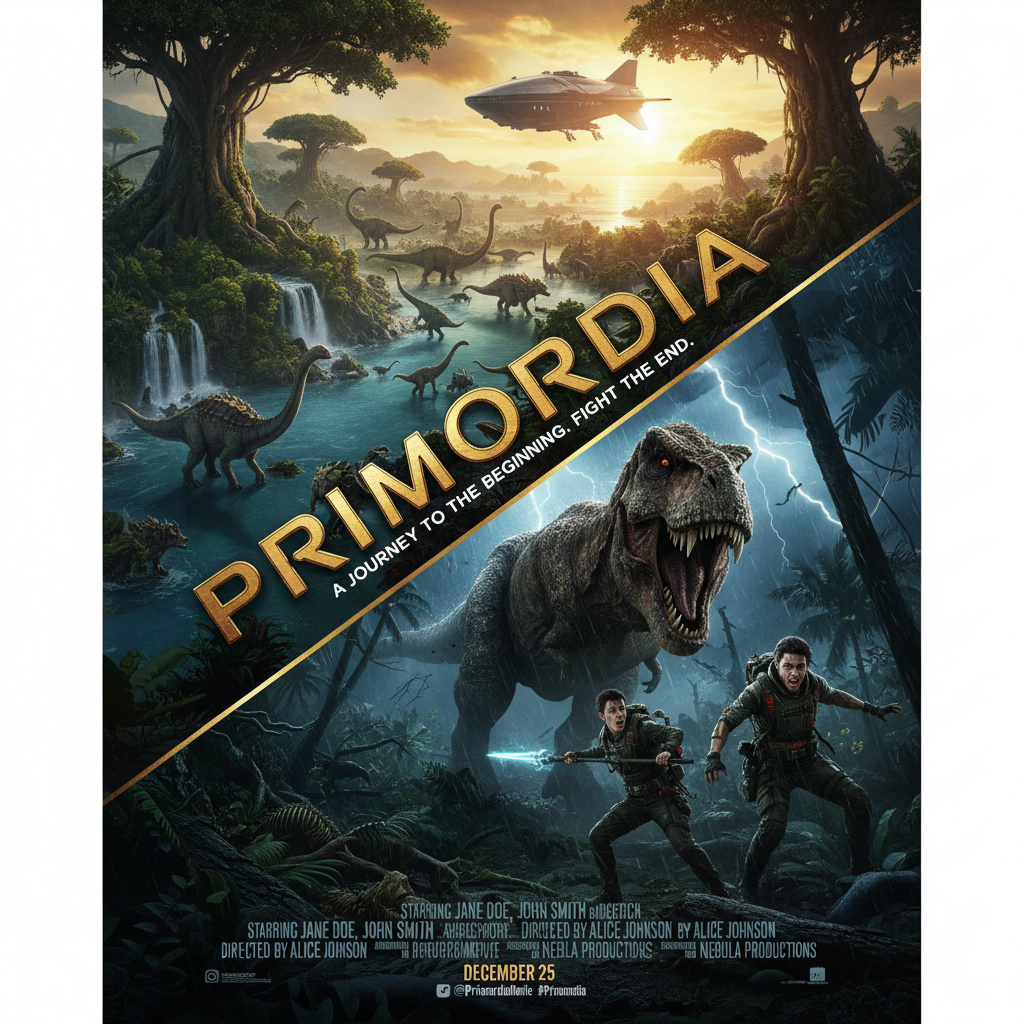

In [ ]:
# Task 8c: Display the saved image (5 pts)
#Ref from Lecture 2 Notebook

from IPython.display import Image, display
if output_path.exists():
    display(Image(filename=str(output_path), width =400))
else:
    print("Re-run previous cell to generate image!")



---

## Task 9: Submit via Pull Request (15 points)

Now let's practice a real-world development workflow! Instead of pushing directly to `main`, you'll create a **branch**, open a **Pull Request (PR)**, and **merge** it.

This is how professional developers submit code for review. Your TA will check your merged PR to verify your submission.

### 9a. Create a new branch (5 pts)

Run this command in your terminal to create and switch to a new branch:

In [ ]:
# Task 9a: Create a new branch (5 pts)
# Run this in your terminal (not in this notebook!)

!git checkout -b homework-2

### 9b. Commit your work (5 pts)

Stage all your changes and create a commit:

In [ ]:
# Task 9b: Commit your work (5 pts)

!git add .
!git commit -m "Complete homework 2: Movie Poster Generator"

In [ ]:
# Task 9c: Push your branch (5 pts)

!git push -u origin homework-2

### 9d. Create and Merge the Pull Request

Now go to your repository on GitHub (https://github.com/YOUR-USERNAME/ai-engineering-fordham):

1. You should see a banner saying **"homework-2 had recent pushes"** - click **"Compare & pull request"**
2. Give your PR a title: `"Homework 2: Movie Poster Generator"`
3. Click **"Create pull request"**
4. Review your changes in the PR
5. Click **"Merge pull request"** then **"Confirm merge"**

**Your PR should now show as "Merged"** - this is what the TA will check!

Run the cell below to verify your branch was merged:

In [ ]:
# Verify your PR was merged (run after merging on GitHub)
!git checkout main
!git pull
!git log --oneline -3

---

## BONUS: Full Pipeline (10 bonus points)

Put everything together! Create a complete pipeline that takes a movie description and returns both the structured data AND a generated poster.

**Challenge:** Write your own original movie description and generate a poster for it!

In [ ]:
# BONUS: Create a complete pipeline (10 bonus pts)

async def movie_to_poster(description: str) -> tuple[Movie, str]:
    """
    Complete pipeline: description -> structured data -> poster
    
    Args:
        description: A text description of a movie
        
    Returns:
        Tuple of (Movie object, path to saved poster image)
    """
    # YOUR CODE HERE
    pass

In [ ]:
# Test with YOUR OWN original movie idea!

my_movie_description = """
YOUR ORIGINAL MOVIE IDEA HERE - BE CREATIVE!
Describe the plot, characters, setting, visual style, and mood.
"""

# Uncomment to run:
# movie, poster_path = await movie_to_poster(my_movie_description)
# print(f"Generated poster for: {movie.title}")
# print(movie.model_dump_json(indent=2))
# display(Image(poster_path))

---

## Submission Checklist

Before submitting, make sure:

- [ ] All code cells run without errors
- [ ] Your `Movie` schema includes all required fields with proper validation
- [ ] `extract_movie()` returns a valid `Movie` object
- [ ] Async processing works and shows timing
- [ ] Temperature comparison shows deterministic vs random outputs
- [ ] Logprobs visualization works and displays token probabilities
- [ ] Reasoning model comparison shows differences between o3-mini and gpt-5-mini
- [ ] You generated and displayed at least one movie poster
- [ ] Created branch `homework-2` and pushed to GitHub
- [ ] Opened a Pull Request from `homework-2` to `main`
- [ ] **Merged the PR** (it should show as "Merged" on GitHub)
- [ ] Submitted notebook on Blackboard

**Submission:**
1. Complete all tasks in this notebook
2. Create a PR and **merge it** on GitHub
3. Submit your notebook (`.ipynb` file) on **Blackboard**

**The TA will verify your submission by checking the merged PR on your GitHub repo.**

---

**Great work!** You've built a complete AI-powered application, explored LLM parameters and reasoning, and learned a professional Git workflow!